# 🧬 Model Development – Immunotherapy Response Prediction
## Hackathon DIGPHAT-CANVAS – PharmacogenomicDay

**Use Case:** Multi-modal prediction of Immunotherapy response for ccRCC patients with follow-up post-Immune Checkpoint Blockade (ICB).

In this notebook we will:
1. Explore & integrate five omics/clinical modalities
2. Define the clinical outcome (RECIST response)
3. Preprocess each data modality (leakage-controlled)
4. Engineer features & reduce dimensionality
5. Train and evaluate multiple ML classifiers
6. Save the best model & preprocessing artifacts for the **Deployment Notebook**

<div style="width:100%; overflow-x: auto; background-color: #ffffff; padding: 20px; border-radius: 8px; border: 1px solid #ddd;">
<svg width="1300" height="650" viewBox="0 0 1300 650" xmlns="http://www.w3.org/2000/svg">
<defs>
  <marker id="arrow-green" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="6" markerHeight="6" orient="auto">
    <path d="M 0 0 L 10 5 L 0 10 z" fill="#70ad47" />
  </marker>
  <marker id="arrow-blue" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="6" markerHeight="6" orient="auto">
    <path d="M 0 0 L 10 5 L 0 10 z" fill="#9dc3e6" />
  </marker>
  <marker id="arrow-purple" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="6" markerHeight="6" orient="auto">
    <path d="M 0 0 L 10 5 L 0 10 z" fill="#c3a4ff" />
  </marker>
  <marker id="arrow-black" viewBox="0 0 10 10" refX="9" refY="5" markerWidth="6" markerHeight="6" orient="auto">
    <path d="M 0 0 L 10 5 L 0 10 z" fill="black" />
  </marker>
</defs>
<style>
  .node-group { cursor: pointer; transition: all 0.2s ease; }
  .node-group:hover rect, .node-group:hover path.cloud { filter: brightness(0.92); stroke-width: 3px; }
  .link-arrow { fill: none; stroke-linecap: round; stroke-linejoin: round; }
</style>

<line class="link-arrow" x1="145" y1="410" x2="205" y2="410" stroke="black" stroke-width="2" marker-end="url(#arrow-black)"/>
<line class="link-arrow" x1="350" y1="410" x2="405" y2="410" stroke="#70ad47" stroke-width="2" marker-end="url(#arrow-green)"/>
<text x="378" y="400" fill="#70ad47" font-size="14" font-weight="bold" font-family="Arial, sans-serif">80%</text>
<line class="link-arrow" x1="280" y1="440" x2="280" y2="545" stroke="#70ad47" stroke-width="2" marker-end="url(#arrow-green)"/>
<text x="305" y="490" fill="#70ad47" font-size="14" font-weight="bold" font-family="Arial, sans-serif">20%</text>
<line class="link-arrow" x1="530" y1="410" x2="570" y2="410" stroke="#70ad47" stroke-width="2" marker-end="url(#arrow-green)"/>
<path class="link-arrow" d="M 550 410 L 550 350 L 240 350 L 240 315" stroke="#9dc3e6" stroke-width="2" marker-end="url(#arrow-blue)"/>
<line class="link-arrow" x1="320" y1="280" x2="335" y2="280" stroke="#9dc3e6" stroke-width="2" marker-end="url(#arrow-blue)"/>
<line class="link-arrow" x1="500" y1="280" x2="515" y2="280" stroke="#9dc3e6" stroke-width="2" marker-end="url(#arrow-blue)"/>
<path class="link-arrow" d="M 680 280 L 725 280 L 725 410 L 755 410" stroke="#9dc3e6" stroke-width="2" marker-end="url(#arrow-blue)"/>
<line class="link-arrow" x1="725" y1="410" x2="755" y2="410" stroke="#9dc3e6" stroke-width="2" marker-end="url(#arrow-blue)"/>
<line class="link-arrow" x1="810" y1="380" x2="810" y2="315" stroke="#c3a4ff" stroke-width="2" marker-end="url(#arrow-purple)"/>
<line class="link-arrow" x1="810" y1="250" x2="810" y2="165" stroke="#c3a4ff" stroke-width="2" marker-end="url(#arrow-purple)"/>
<line class="link-arrow" x1="740" y1="130" x2="725" y2="130" stroke="#c3a4ff" stroke-width="2" marker-end="url(#arrow-purple)"/>
<line class="link-arrow" x1="880" y1="130" x2="925" y2="130" stroke="#c3a4ff" stroke-width="2" marker-end="url(#arrow-purple)"/>
<line class="link-arrow" x1="1000" y1="160" x2="1000" y2="245" stroke="#c3a4ff" stroke-width="2" marker-end="url(#arrow-purple)"/>
<line class="link-arrow" x1="1000" y1="310" x2="1000" y2="375" stroke="#c3a4ff" stroke-width="2" marker-end="url(#arrow-purple)"/>
<line class="link-arrow" x1="1100" y1="280" x2="1075" y2="280" stroke="#c3a4ff" stroke-width="2" marker-end="url(#arrow-purple)"/>
<line class="link-arrow" x1="920" y1="440" x2="920" y2="545" stroke="black" stroke-width="2" marker-end="url(#arrow-black)"/>
<line class="link-arrow" x1="810" y1="580" x2="365" y2="580" stroke="black" stroke-width="2" marker-end="url(#arrow-black)"/>
<a href="#anch-preprocessing"><g class="node-group">\n<rect class="cloud" x="40.0" y="370.0" width="140" height="80" rx="35" ry="35" fill="#ffffff" stroke="#000000" stroke-width="2"/>\n<text x="110" y="406" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Original</text>\n<text x="110" y="424" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Dataset</text>\n</g></a>
<a href="#anch-preprocessing"><g class="node-group">\n<rect x="210.0" y="380.0" width="140" height="60" rx="10" fill="#e2efda" stroke="#70ad47" stroke-width="2"/>\n<text x="280" y="406" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Data splitting</text>\n<text x="280" y="424" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">80:20</text>\n</g></a>
<a href="#anch-preprocessing"><g class="node-group">\n<rect x="410.0" y="380.0" width="120" height="60" rx="10" fill="#e2efda" stroke="#70ad47" stroke-width="2"/>\n<text x="470" y="406" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Training</text>\n<text x="470" y="424" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">set</text>\n</g></a>
<a href="#anch-preprocessing"><g class="node-group">\n<rect x="575.0" y="380.0" width="150" height="60" rx="10" fill="#ddebf7" stroke="#9dc3e6" stroke-width="2"/>\n<text x="650" y="406" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Data</text>\n<text x="650" y="424" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">preprocessing</text>\n</g></a>
<a href="#anch-preprocessing"><g class="node-group">\n<rect x="160.0" y="250.0" width="160" height="60" rx="10" fill="#ddebf7" stroke="#9dc3e6" stroke-width="2"/>\n<text x="240" y="276" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Duplicated data</text>\n<text x="240" y="294" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">handling</text>\n</g></a>
<a href="#anch-missing"><g class="node-group">\n<rect x="340.0" y="250.0" width="160" height="60" rx="10" fill="#ddebf7" stroke="#9dc3e6" stroke-width="2"/>\n<text x="420" y="276" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Missing values</text>\n<text x="420" y="294" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">imputation</text>\n</g></a>
<a href="#anch-preprocessing"><g class="node-group">\n<rect x="520.0" y="250.0" width="160" height="60" rx="10" fill="#ddebf7" stroke="#9dc3e6" stroke-width="2"/>\n<text x="600" y="276" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Data</text>\n<text x="600" y="294" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">harmonization</text>\n</g></a>
<a href="#anch-baseline"><g class="node-group">\n<rect x="760.0" y="380.0" width="320" height="60" rx="10" fill="#e2d2ff" stroke="#c3a4ff" stroke-width="2"/>\n<text x="920" y="414" fill="black" font-size="15" font-weight="bold" font-family="Arial, sans-serif" text-anchor="middle">Model development</text>\n</g></a>
<a href="#anch-cv"><g class="node-group">\n<rect x="740.0" y="250.0" width="140" height="60" rx="10" fill="#e2d2ff" stroke="#c3a4ff" stroke-width="2"/>\n<text x="810" y="276" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Data</text>\n<text x="810" y="294" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">normalization</text>\n</g></a>
<a href="#anch-optimization"><g class="node-group">\n<rect x="740.0" y="100.0" width="140" height="60" rx="10" fill="#fae8ff" stroke="#ffc000" stroke-width="2"/>\n<text x="810" y="126" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Feature</text>\n<text x="810" y="144" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">engineering</text>\n</g></a>
<a href="#anch-optimization"><g class="node-group">\n<rect x="560.0" y="100.0" width="160" height="60" rx="10" fill="#fae8ff" stroke="#ffc000" stroke-width="2"/>\n<text x="640" y="126" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Feature selection</text>\n<text x="640" y="144" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Dimension reduction</text>\n</g></a>
<a href="#anch-cv"><g class="node-group">\n<rect x="930.0" y="100.0" width="140" height="60" rx="10" fill="#e2d2ff" stroke="#c3a4ff" stroke-width="2"/>\n<text x="1000" y="126" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Model</text>\n<text x="1000" y="144" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">selection</text>\n</g></a>
<a href="#anch-hyper"><g class="node-group">\n<rect x="930.0" y="250.0" width="140" height="60" rx="10" fill="#fae8ff" stroke="#c0504d" stroke-width="2"/>\n<text x="1000" y="284" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Optimization</text>\n</g></a>
<a href="#anch-hyper"><g class="node-group">\n<rect x="1100.0" y="250.0" width="160" height="60" rx="10" fill="#fae8ff" stroke="#c0504d" stroke-width="2"/>\n<text x="1180" y="276" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Data Sampling</text>\n<text x="1180" y="294" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Hyperparameter tunning</text>\n</g></a>
<a href="#anch-submission"><g class="node-group">\n<rect x="810.0" y="550.0" width="220" height="60" rx="10" fill="#f2f2f2" stroke="#7f7f7f" stroke-width="3"/>\n<text x="920" y="576" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">Selected model</text>\n<text x="920" y="594" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">configuration</text>\n</g></a>
<a href="#anch-submission"><g class="node-group">\n<rect x="200.0" y="550.0" width="160" height="60" rx="10" fill="#fce4d6" stroke="#ff0000" stroke-width="3"/>\n<text x="280" y="584" fill="black" font-size="15" font-weight="normal" font-family="Arial, sans-serif" text-anchor="middle">External validation</text>\n</g></a>
<text x="965" y="195" fill="red" font-size="20" font-weight="bold" font-family="Arial, sans-serif" text-anchor="middle">K-fold</text>
<text x="965" y="225" fill="red" font-size="20" font-weight="bold" font-family="Arial, sans-serif" text-anchor="middle">cross validation</text>
</svg>
</div>

In [37]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, learning_curve
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import miceforest as mf
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import importlib.machinery, importlib.util
import mygene
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
RANDOM_STATE = 42

def plot_pca_2d(X_data, y_labels, title="2D PCA Projection", random_state=42, ax=None):
    """
    Fits a 2D PCA on the provided features and plots the result colored by labels.
    """
    pca_2d = PCA(n_components=2, random_state=random_state)
    X_pca_2d = pca_2d.fit_transform(X_data)
    
    pca_df = pd.DataFrame(data=X_pca_2d, columns=['PC1', 'PC2'])
    if hasattr(y_labels, 'reset_index'):
        pca_df['Response'] = y_labels.reset_index(drop=True)
    else:
        pca_df['Response'] = y_labels

    # Nếu không truyền ax, tạo figure mới
    if ax is None:
        plt.figure(figsize=(8, 6))
        ax = plt.gca()
        
    sns.scatterplot(
        x='PC1', y='PC2', hue='Response', data=pca_df, 
        palette={0: 'darkorange', 1: 'steelblue'}, alpha=0.7, s=60, ax=ax
    )
    
    var_ratio = pca_2d.explained_variance_ratio_ * 100
    ax.set_xlabel(f'PC1 ({var_ratio[0]:.1f}%)')
    ax.set_ylabel(f'PC2 ({var_ratio[1]:.1f}%)')
    ax.set_title(title)
    ax.legend(title='Response', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.5)


def convert_ensembl_to_hugo(ensembl_ids):
    """
    Converts a list of Ensembl IDs to HUGO Symbols using MyGeneInfo.
    """
    mg = mygene.MyGeneInfo()
    
    # 1. Clean IDs: Remove version suffixes (e.g., ENSG00000139618.15 -> ENSG00000139618)
    # This is important as MyGeneInfo scopes usually match the base ID.
    clean_ids = [eid.split('.')[0] for eid in ensembl_ids]
    
    # 2. Query MyGeneInfo
    # scopes: defines what the input IDs are
    # fields: what data we want back (symbol is the HUGO ID)
    results = mg.querymany(
        clean_ids, 
        scopes='ensembl.gene', 
        fields='symbol', 
        species='human',
        verbose=False
    )
    
    # 3. Process results into a mapping
    # Note: querymany returns a list of dictionaries
    mapping = {}
    for res in results:
        query_id = res['query']
        symbol = res.get('symbol')  # This is the HUGO Symbol
        
        if symbol:
            mapping[query_id] = symbol
        else:
            mapping[query_id] = "Not Found"
            
    return mapping


_loader = importlib.machinery.SourcelessFileLoader("evaluator", "evaluator.pyc")
_spec = importlib.util.spec_from_loader("evaluator", _loader)
_mod = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_mod)
evaluator = _mod.evaluate

print("All imports OK ✅")

All imports OK ✅


---
# 1. Objective & Clinical Question

**Clinical question:** Can we predict RECIST response (CR/PR/SD vs PD) to immunotherapy from multi-modal patient data?

| Item | Detail |
|------|--------|
| Tumor type | Clear-cell Renal Cell Carcinoma (ccRCC) |
| Treatment | Immune Checkpoint Blockade (Nivolumab) |
| Outcome | Binary RECIST: **Non-progressor** (CR/PR/SD) vs **Progressor** (PD) |
| Sites | Primary + metastatic samples |

---
# 2. Dataset Overview

## 2.1 Modalities

| # | Modality | Description |
|---|----------|-------------|
| 1 | **Clinical** | Demographics, treatment, tumour characteristics, RECIST |
| 2 | **Genomic** | Somatic mutations & copy-number alterations |
| 3 | **Immune deconvolution** | [CIBERSORTx](https://cibersortx.stanford.edu/) cell-type proportions from bulk RNA-seq |
| 4 | **Pathway scores** | ssGSEA scores for 50 [Hallmark pathways](https://www.gsea-msigdb.org/gsea/msigdb/human/genesets.jsp?collection=H) |
| 5 | **Transcriptomic** | Gene-level TPM expression (~40 k genes) |

---
The cohort is collected from the study by Braun et al. (2020) [Nature Medicine](https://www.nature.com/articles/s41591-020-0839-y) consisting of ccRCC patients treated with Nivolumab. We split the data into a training set (80%) and a hold-out test set (20%) for final evaluation.

- The **training set** → used in this notebook for model development (with cross-validation).
- The **test set** → held out for the blind evaluation.

In [2]:
# ── Load all modalities ──────────────────────────────────────────────
nivo_clinical = pd.read_csv('Data/train_nivo/clinical.csv')
nivo_genomic  = pd.read_csv('Data/train_nivo/genomic.csv')
nivo_ssgsea   = pd.read_csv('Data/train_nivo/ssgsea.csv')
nivo_deconv   = pd.read_csv('Data/train_nivo/cell_deconvolution.csv')
nivo_transcriptomic = pd.read_csv('Data/train_nivo/transcriptomic.csv')

# ── Quick look at each modality ───────────────────────────────────────────────
for name, df in [('Clinical', nivo_clinical), ('Genomic', nivo_genomic),
                 ('Deconvolution', nivo_deconv), ('ssGSEA', nivo_ssgsea),
                 ('Transcriptomic', nivo_transcriptomic)]:
    print(f"\n{'='*60}")
    print(f"  {name}: Shape = {df.shape}")
    print(f"{'='*60}")
    display(df.head(3))


  Clinical: Shape = (137, 11)


,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis,ORR
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,62.0,FAVORABLE,No,No,2.0,PRIMARY,SD
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,62.0,POOR,No,No,1.0,PRIMARY,PR
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,46.0,FAVORABLE,No,No,3.0,PRIMARY,SD



  Genomic: Shape = (137, 34)


,Patient_ID,Amplification_5q31.3,Amplification_5q35.3,Deletion_3p21.1,Deletion_6p22.2,Deletion_6p21.32,Deletion_6p12.1,Deletion_9p21.3,Deletion_9q34.3,Deletion_10q23.31,...,SETD2,SMARCA4,TCEB1,TP53,TRMT2B,TSC1,USP32,VHL,WNT8A,ZNF800
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,...,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,MUT,MUT,MUT,WT,WT,WT,WT,WT,WT,...,WT,WT,WT,WT,WT,WT,WT,MUT,WT,WT
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,...,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF



  Deconvolution: Shape = (137, 27)


,Patient_ID,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),...,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE,Absolute score (sig.score)
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.046327,0.086641,0.015842,0.185357,0.0,0.204351,0.022605,0.050186,0.009508,...,0.042027,0.021309,0.057458,0.0,0.009780,0.053686,0,0.923779,0.650795,1.274922
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,0.069083,0.050311,0.035438,0.101136,0.0,0.179168,0.035013,0.087914,0.000000,...,0.023344,0.019054,0.094429,0.0,0.000000,0.075189,0,0.917443,0.667743,1.304494
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,0.160051,0.012883,0.012708,0.202380,0.0,0.157942,0.091704,0.100219,0.000000,...,0.019324,0.017143,0.042158,0.0,0.001491,0.067586,0,0.915876,0.657080,1.417939



  ssGSEA: Shape = (137, 51)


,Patient_ID,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,...,HALLMARK_PROTEIN_SECRETION,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,HALLMARK_SPERMATOGENESIS,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,HALLMARK_UV_RESPONSE_DN,HALLMARK_UV_RESPONSE_UP,HALLMARK_WNT_BETA_CATENIN_SIGNALING,HALLMARK_XENOBIOTIC_METABOLISM
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,0.645208,0.613143,0.640741,0.544471,0.477824,0.356894,0.653818,0.393865,0.589824,...,0.792464,0.729333,0.128080,0.670299,0.571636,0.717934,0.662968,0.512491,0.432010,0.477736
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,0.745334,0.481716,0.692472,0.656193,0.583043,0.523270,0.671667,0.518503,0.672382,...,0.821810,0.773135,0.139733,0.745215,0.604999,0.734874,0.713620,0.574449,0.514951,0.629333
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,0.693889,0.433513,0.657505,0.449349,0.506846,0.336111,0.627200,0.462714,0.694758,...,0.821017,0.765573,0.189356,0.666627,0.503043,0.777414,0.591643,0.585362,0.419669,0.541380



  Transcriptomic: Shape = (137, 40935)


,Patient_ID,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,ENSG00000238009.6,ENSG00000239945.1,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
0,G138701_RCCBMS-00020-T_v1_RNA_OnPrem,22.45228,34.75424,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,32.02459,32.43928,28.87370,29.40491,34.00210,21.13002,31.87140,31.90028,21.26386,28.67162
1,G138701_RCCBMS-00141-T_v1_RNA_OnPrem,26.08813,33.57834,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,33.92360,33.17470,32.86634,32.95676,34.37301,21.13002,33.46758,32.99777,21.26386,33.29667
2,G138701_RCCBMS-00053-T_v1_RNA_OnPrem,33.52886,32.94687,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,33.62518,29.16648,28.87370,29.40491,32.96280,21.13002,31.33387,32.84050,21.26386,28.67162


### 2.1.2 Load Hold-out Test Data
We also load the hold-out **test set**, which will be strictly used for the final blind model evaluation at the bottom of this notebook. 

**Crucial Rule:** The model and all preprocessing objects (e.g., imputers, scalers, PCA) will ONLY be fitted (trained) on the **training set**. 
The test data is then passed through these pre-fitted transformations. It NEVER participates in calculating parameters like scaling factors, preventing Data Leakage and simulating a real-world clinical deployment.

In [3]:
# ── Load Test Set Modalities ──────────────────────────────────────────────
nivo_clinical_test = pd.read_csv('Data/test_nivo/clinical.csv')
nivo_genomic_test  = pd.read_csv('Data/test_nivo/genomic.csv')
nivo_ssgsea_test   = pd.read_csv('Data/test_nivo/ssgsea.csv')
nivo_deconv_test   = pd.read_csv('Data/test_nivo/cell_deconvolution.csv')
nivo_transcriptomic_test = pd.read_csv('Data/test_nivo/transcriptomic.csv')

for name, df in [('Clinical Test', nivo_clinical_test), ('Genomic Test', nivo_genomic_test),
                 ('Deconvolution Test', nivo_deconv_test), ('ssGSEA Test', nivo_ssgsea_test),
                 ('Transcriptomic Test', nivo_transcriptomic_test)]:
    print(f"\n{'='*60}")
    print(f"  {name}: Shape = {df.shape}")
    print(f"{'='*60}")
    display(df.head(3))


  Clinical Test: Shape = (35, 10)


,Patient_ID,Cohort,Arm,Sex,Age,MSKCC,Sarc,Rhab,Number_of_Prior_Therapies,Tumor_Sample_Primary_or_Metastasis
0,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Female,67.0,FAVORABLE,No,No,2.0,PRIMARY
1,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,60.0,FAVORABLE,No,No,3.0,PRIMARY
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,CM-010,NIVOLUMAB,Male,76.0,INTERMEDIATE,No,No,2.0,PRIMARY



  Genomic Test: Shape = (35, 34)


,Patient_ID,Amplification_5q31.3,Amplification_5q35.3,Deletion_3p21.1,Deletion_6p22.2,Deletion_6p21.32,Deletion_6p12.1,Deletion_9p21.3,Deletion_9q34.3,Deletion_10q23.31,...,SETD2,SMARCA4,TCEB1,TP53,TRMT2B,TSC1,USP32,VHL,WNT8A,ZNF800
0,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,MUT,MUT,MUT,MUT,WT,WT,MUT,MUT,WT,...,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT
1,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,...,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF,NO_IF
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,WT,WT,MUT,WT,WT,WT,MUT,MUT,MUT,...,WT,WT,WT,WT,WT,WT,WT,WT,WT,WT



  Deconvolution Test: Shape = (35, 27)


,Patient_ID,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),...,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils,P-value,Correlation,RMSE,Absolute score (sig.score)
0,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,0.069574,0.066311,0.011640,0.094022,0.0,0.192493,0.026367,0.093081,0.0,...,0.051978,0.042653,0.095057,0.013068,0.001785,0.032963,0,0.940515,0.657605,1.294824
1,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,0.077481,0.047750,0.009711,0.102434,0.0,0.218811,0.014836,0.063674,0.0,...,0.021808,0.049866,0.129722,0.000000,0.009661,0.054593,0,0.885100,0.688182,1.280054
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,0.014722,0.085358,0.009111,0.049616,0.0,0.208555,0.057945,0.098924,0.0,...,0.016985,0.005598,0.084503,0.000000,0.019692,0.055920,0,0.888383,0.686416,1.163864



  ssGSEA Test: Shape = (35, 51)


,Patient_ID,HALLMARK_ADIPOGENESIS,HALLMARK_ALLOGRAFT_REJECTION,HALLMARK_ANDROGEN_RESPONSE,HALLMARK_ANGIOGENESIS,HALLMARK_APICAL_JUNCTION,HALLMARK_APICAL_SURFACE,HALLMARK_APOPTOSIS,HALLMARK_BILE_ACID_METABOLISM,HALLMARK_CHOLESTEROL_HOMEOSTASIS,...,HALLMARK_PROTEIN_SECRETION,HALLMARK_REACTIVE_OXYGEN_SPECIES_PATHWAY,HALLMARK_SPERMATOGENESIS,HALLMARK_TGF_BETA_SIGNALING,HALLMARK_TNFA_SIGNALING_VIA_NFKB,HALLMARK_UNFOLDED_PROTEIN_RESPONSE,HALLMARK_UV_RESPONSE_DN,HALLMARK_UV_RESPONSE_UP,HALLMARK_WNT_BETA_CATENIN_SIGNALING,HALLMARK_XENOBIOTIC_METABOLISM
0,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,0.730727,0.460351,0.673872,0.615952,0.518616,0.347035,0.641102,0.454217,0.659935,...,0.809339,0.752864,0.136680,0.686237,0.539509,0.764915,0.683743,0.542750,0.444790,0.557659
1,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,0.679611,0.475361,0.668262,0.533761,0.504437,0.352142,0.600118,0.418543,0.605789,...,0.778930,0.703088,0.123041,0.689171,0.500487,0.711850,0.703328,0.458970,0.454441,0.509802
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,0.756409,0.462137,0.704921,0.596222,0.552728,0.398848,0.646143,0.456058,0.698500,...,0.822478,0.756662,0.131104,0.769317,0.582469,0.764036,0.716527,0.572508,0.487859,0.532403



  Transcriptomic Test: Shape = (35, 40935)


,Patient_ID,ENSG00000223972.5,ENSG00000227232.5,ENSG00000284332.1,ENSG00000237613.2,ENSG00000268020.3,ENSG00000240361.2,ENSG00000186092.7,ENSG00000238009.6,ENSG00000239945.1,...,ENSG00000198899.2,ENSG00000198938.2,ENSG00000198840.2,ENSG00000212907.2,ENSG00000198886.2,ENSG00000210176.1,ENSG00000198786.2,ENSG00000198695.2,ENSG00000210194.1,ENSG00000198727.2
0,G138701_RCCBMS-00097-T_v1_RNA_OnPrem,27.91941,34.70075,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,34.67436,34.35974,33.35211,34.23558,34.75711,21.13002,33.69635,33.57917,21.26386,33.96374
1,G138701_RCCBMS-00099-T_v1_RNA_OnPrem,22.45228,33.48258,22.43516,21.0431,21.0536,21.01001,25.69254,22.39925,21.51332,...,33.25229,32.88098,33.23512,34.18982,34.09013,21.13002,33.52007,33.08947,21.26386,32.90812
2,G138701_RCCBMS-00163-T_v1_RNA_OnPrem,22.45228,34.02825,22.43516,21.0431,21.0536,21.01001,20.83447,22.39925,21.51332,...,27.94141,29.16648,28.87370,29.40491,32.73904,21.13002,30.58496,28.49402,21.26386,28.67162


## 2.2. Data Description

In [4]:
# ── Training data summary ────────────────────────────────────────────────────────────
print(f"Total patients: {len(nivo_clinical)}")
print(f"\nORR distribution:")
print(nivo_clinical['ORR'].value_counts().to_string())
print(f"\nCohorts: {nivo_clinical['Cohort'].unique()}")
print(f"Treatment arms: {nivo_clinical['Arm'].unique()}")

Total patients: 137

ORR distribution:
ORR
SD      53
PD      53
CRPR    22
PR       9

Cohorts: <ArrowStringArray>
['CM-010', 'CM-025', 'CM-009']
Length: 3, dtype: str
Treatment arms: <ArrowStringArray>
['NIVOLUMAB']
Length: 1, dtype: str


### 2.2.1. Outcome Definition
We define a **binary** outcome for immunotherapy response:
- **1 (Non-progressor):** CR (Complete Response), PR (Partial Response), CRPR, SD (Stable Disease)
- **0 (Progressor):** PD (Progressive Disease)

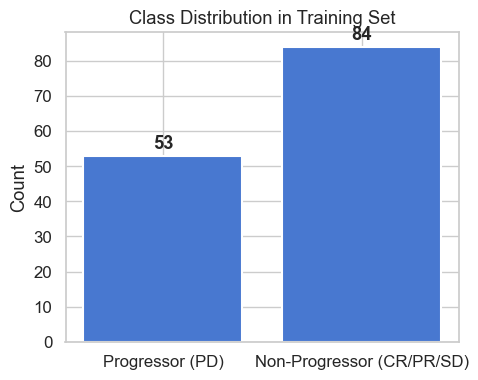

Progressor: 84  |  Non-Progressor: 53  |  Ratio: 1:0.6


In [5]:
# ── Map Response (RECIST) ────────────────────────────────────────────
response_map = {'CR': 1, 'PR': 1, 'CRPR': 1, 'SD': 1, 'PD': 0}
nivo_clinical['Response'] = nivo_clinical['ORR'].map(response_map)
y_nivo = nivo_clinical['Response'].values

resp_counts = nivo_clinical['Response'].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Progressor (PD)', 'Non-Progressor (CR/PR/SD)'], resp_counts.values, edgecolor='white', linewidth=1.5)
for b in bars:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 2,
            str(int(b.get_height())), ha='center', fontweight='bold')
ax.set_ylabel('Count'); ax.set_title('Class Distribution in Training Set')
plt.tight_layout(); plt.show()

ratio = resp_counts[1] / resp_counts[0]
print(f"Progressor: {resp_counts[1]}  |  Non-Progressor: {resp_counts[0]}  |  Ratio: 1:{1/ratio:.1f}")

### 2.2.2 Missing Data

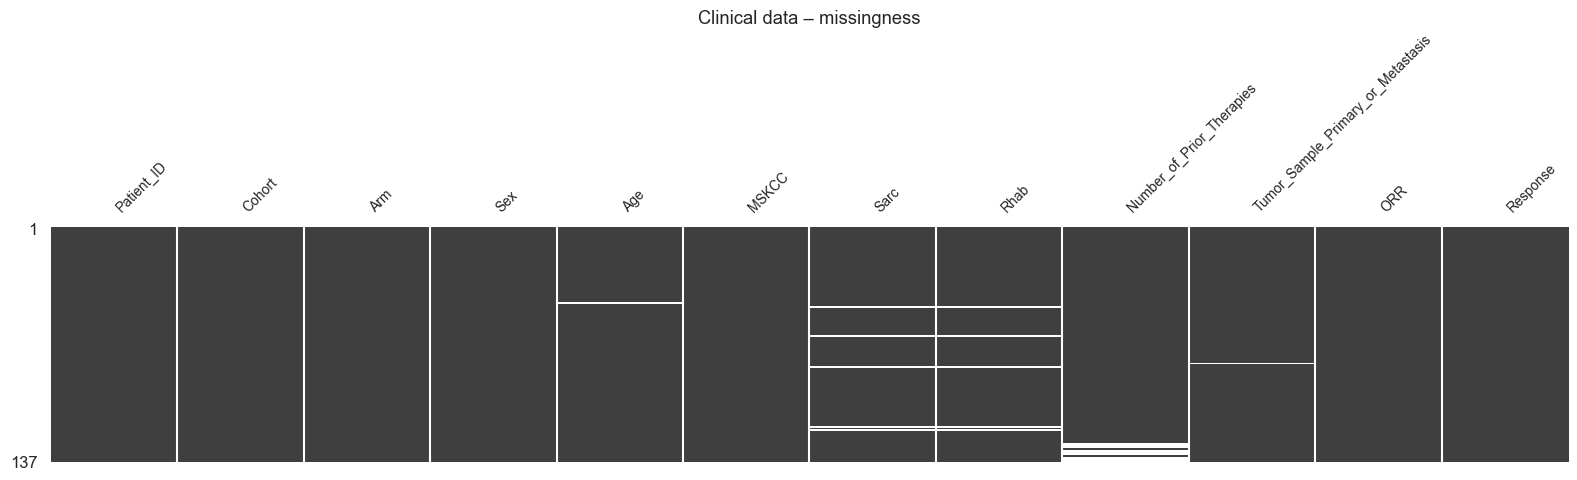

Total missing values in transcriptomic data: 0


In [6]:
fig, axes = plt.subplots(1,1, figsize=(16, 5))
msno.matrix(nivo_clinical, ax=axes, sparkline=False, fontsize=10)
axes.set_title('Clinical data – missingness')
plt.tight_layout()
plt.show()

print(f"Total missing values in transcriptomic data: {nivo_transcriptomic.isna().sum().sum()}")

<a id="anch-preprocessing"></a>\n\n
<a id="data-preprocessing"></a>

# 3. Data Preprocessing & Feature Engineering

> **Leakage-controlled:** Every transformation (scaling, imputation, PCA, feature
> selection) is **fit on the training set only** and later applied to the test set.

## 3.1 Transcriptomic Data (RNA-seq)

The expression matrix contains **~40 000 genes** measured in **TPM** (Transcripts Per Million).

**Pre-processing steps:**
- The data is **already normalised to TPM**.
- We **filter low-expression genes** by removing genes below a variance threshold.
- We **standardise** the remaining genes.
- Sometimes, Gene identifiers are Ensembl IDs (e.g. `ENSG00000141510.18`).
  In a production pipeline you would convert them to HUGO symbols (`mygene` library, etc.). Here we keep Ensembl IDs for simplicity.

In [7]:
# Calculate variance for all genes
# ── 3.1 Transcriptomic Processing ────────────────────────────────────────────
transcriptomic_train = nivo_transcriptomic.drop('Patient_ID', axis=1).copy()
gene_var = transcriptomic_train.var()

# Select the top 100 features with the highest variance
# .sort_values(ascending=False) puts the highest variance at the top
keep_genes = gene_var.sort_values(ascending=False).head(100).index.tolist()

nivo_transcriptomic_filtered = transcriptomic_train[keep_genes]

print(f"Genes kept after variance filter: {len(keep_genes)}")
print(f"Transcriptomic feature matrix: {nivo_transcriptomic_filtered.shape}")


Genes kept after variance filter: 100
Transcriptomic feature matrix: (137, 100)


In [38]:
# Apply the exact same gene filter to the hold-out test set to maintain feature alignment.
test_transcriptomic_filtered = nivo_transcriptomic_test[keep_genes]

## 3.2 Clinical Data

### 3.2.1. Data encoding

- **Ordinal variables** (MSKCC, Number_of_Prior_Therapies) → ordinal encoding

- **Binary variables** (Sarc, Rhab, Sex, Tumor_Sample_Primary_or_Metastasis) → binary encoding

In [10]:
# ── 3.2 Clinical preprocessing ────────────────────────────────────────────
# Drop identifying and raw outcome columns from the training set.
clinical_train = nivo_clinical.drop(columns=['Patient_ID', 'Cohort', 'Arm', 'ORR', 'Response']).copy()

# 'NO_IF' means 'No Information', which we treat as formally Missing (NaN)
for col in ['Sarc', 'Rhab', 'MSKCC']:
    clinical_train[col] = clinical_train[col].replace('NO_IF', np.nan)

# Initialize a dictionary to store transformers (encoders) so they can be reused on test data without leakage.
transformers = {}

# 1. Binary encoding 
binary_cols = ['Sex', 'Sarc', 'Rhab', 'Tumor_Sample_Primary_or_Metastasis']
ordinal_cols = ['MSKCC','Number_of_Prior_Therapies']
num_cols = ['Age']
for col in binary_cols:
    le = LabelEncoder()
    mask = clinical_train[col].notna() # Only fit on non-missing data rows
    vals = clinical_train.loc[mask, col].astype(str)
    encoded = le.fit_transform(vals)
    
    new_col = pd.Series(np.nan, index=clinical_train.index, dtype=float)
    new_col.loc[mask] = encoded.astype(float)
    clinical_train[col] = new_col
    transformers[f'le_{col}'] = le

# 2. Ordinal encoding for MSKCC (Clinical Risk Score)
mskcc_map = {'POOR': 0, 'INTERMEDIATE': 1, 'FAVORABLE': 2}
clinical_train['MSKCC'] = clinical_train['MSKCC'].map(mskcc_map)
transformers['oe_MSKCC'] = mskcc_map

print(f"Encoders captured: {list(transformers.keys())}")

Encoders captured: ['le_Sex', 'le_Sarc', 'le_Rhab', 'le_Tumor_Sample_Primary_or_Metastasis', 'oe_MSKCC']


In [11]:
# ── Process the Test Clinical Data ─────────────────────────────────────────
clinical_test = nivo_clinical_test.drop(columns=['Patient_ID', 'Cohort', 'Arm']).copy()

for col in ['Sarc', 'Rhab', 'MSKCC']:
    clinical_test[col] = clinical_test[col].replace('NO_IF', np.nan)

# Apply previously fitted LabelEncoders cleanly onto the test set
for col in binary_cols:
    le =  transformers[f'le_{col}']
    mask_test = clinical_test[col].notna()
    vals_test = clinical_test.loc[mask_test, col].astype(str)
    encoded_test = le.transform(vals_test)
    
    new_col_test = pd.Series(np.nan, index=clinical_test.index, dtype=float)
    new_col_test.loc[mask_test] = encoded_test.astype(float)
    clinical_test[col] = new_col_test

# Apply Ordinal Map for test set
clinical_test['MSKCC'] = clinical_test['MSKCC'].map(mskcc_map)

Missing values before imputation: 54


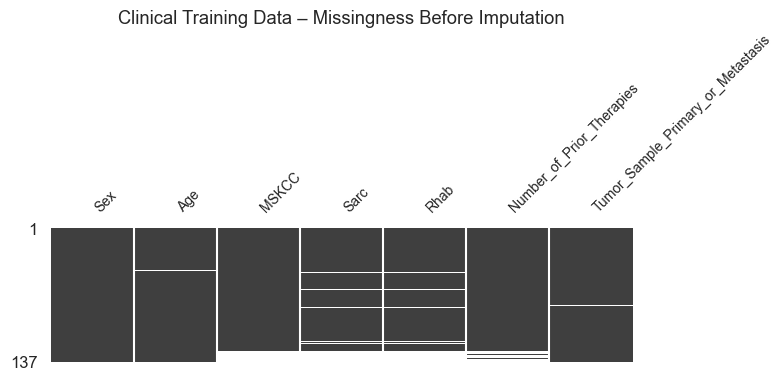

In [12]:
# Missing values check before imputation
missing_before = clinical_train.isna().sum().sum()
print(f"Missing values before imputation: {missing_before}")

# Visualize missingness structurally in clinical data 
fig, ax = plt.subplots(figsize=(8, 4))
msno.matrix(clinical_train, ax=ax, sparkline=False, fontsize=10)
plt.title('Clinical Training Data – Missingness Before Imputation')
plt.tight_layout()
plt.show()  

<a id="anch-missing"></a>\n\n
### 3.2.2. Handling Missing Values in Clinical Data

We impute missing values using **MICE** (Multiple Imputation by Chained Equations) via the `miceforest` library.

In [13]:
# Create an explicitly typed copy for MICE
clinic_for_mice = clinical_train.copy().astype(float)

# MICE imputation (IMPORTANT: We DO NOT include the Response target during imputation to avoid data leakage)
kernel_nivo = mf.ImputationKernel(clinic_for_mice, random_state=RANDOM_STATE)   
kernel_nivo.mice(iterations=10, verbose=False) # 10 iterations of chained equations
clinical_train_imputed = kernel_nivo.complete_data()

print(f'Clinical imputed shape: {clinical_train_imputed.shape}')
print(f'Missing after MICE: {clinical_train_imputed.isna().sum().sum()}')

Clinical imputed shape: (137, 7)
Missing after MICE: 0


In [14]:
# Use the trained ImputationKernel from the training data to impute new test data
clinic_for_mice_test = clinical_test.copy().astype(float)
clinical_test_imputed = kernel_nivo.impute_new_data(clinic_for_mice_test).complete_data()

print(f'Clinical test imputed shape: {clinical_test.shape}')
print(f'Missing after MICE: {clinical_test_imputed.isna().sum().sum()}')

Clinical test imputed shape: (35, 7)
Missing after MICE: 0


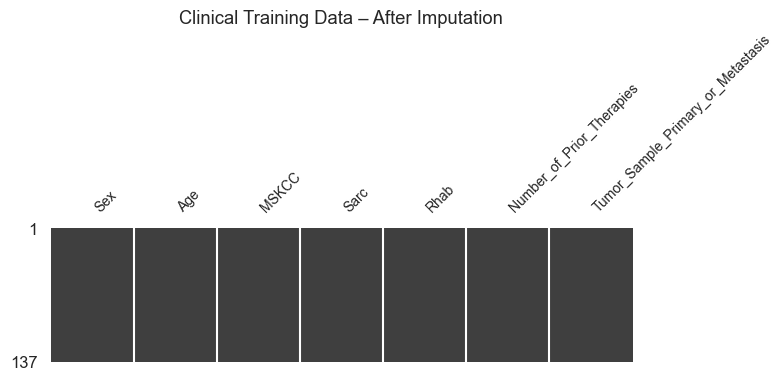

In [15]:
# Visualize missingness remaining after proper imputation
fig, ax = plt.subplots(figsize=(8, 4))
msno.matrix(clinical_train_imputed, ax=ax, sparkline=False, fontsize=10)
plt.title('Clinical Training Data – After Imputation')
plt.tight_layout()
plt.show()  

## 3.3 Somatic Mutation Data


The genomic dataset contains somatic **mutation status** and **copy-number alterations**.

Values: `MUT` (mutated) / `WT` (wild-type) / **`NO_IF`** (no information).

We can treat these as categorical features, but we need to handle the `NO_IF` values carefully. We can consider it as missing values or as a separate category, depending on the context. Here, we treat `NO_IF` as the third category.

In [22]:
# ── Genomic encoding ─────────────────────────────────────────────────
nivo_gen = nivo_genomic.set_index('Patient_ID')

# nivo_gen_encoded = nivo_gen.replace({'MUT': 1, 'WT': 0, 'NO_IF': np.nan}).astype(float)
nivo_gen_encoded = nivo_gen.replace({'MUT': 1, 'WT': 0, 'NO_IF': 2}).astype(float).reset_index(drop=True)

print(f'Genomic shape: {nivo_gen_encoded.shape}')

Genomic shape: (137, 33)


In [17]:
test_gen_encoded = nivo_genomic_test.set_index('Patient_ID').replace({'MUT':1, 'WT':0, 'NO_IF':2}).astype(float)
test_gen_encoded = test_gen_encoded[nivo_gen_encoded.columns].reset_index(drop=True)

## 3.4 ssGSEA Pathway Scores (Hallmark)

50 Hallmark pathway enrichment scores computed with [GSEAPy](https://gseapy.readthedocs.io/).
```python
import gseapy as gp
# txt, gct file input
ss = gp.ssgsea(data='./tests/extdata/Leukemia_hgu95av2.trim.txt',
               gene_sets='./tests/extdata/h.all.v7.0.symbols.gmt',
               outdir=None,
               sample_norm_method='rank', # choose 'custom' will only use the raw value of `data`
               no_plot=True)
```

In [18]:
# ── Pathway (ssGSEA) ────────────────────────────────────────────────
nivo_pathway = nivo_ssgsea.drop('Patient_ID', axis=1).copy()
print(f'Pathway features: {nivo_pathway.shape[1]}')

nivo_pathway_test =  nivo_ssgsea_test.drop('Patient_ID', axis=1).copy()

Pathway features: 50


## 3.5 Immune Cell Deconvolution (CIBERSORTx)

Cell-type proportions estimated from bulk RNA-seq. We leverage the [CIBERSORTx](https://cibersortx.stanford.edu/) tool to deconvolve bulk transcriptomic data into immune cell-type proportions. The output consists of relative abundances of various immune cell types (e.g., CD8+ T cells, macrophages, etc.) for each sample. 

We used LM22 signature matrix for deconvolution, which includes 22 immune cell types. The resulting cell-type proportions are compositional data (i.e., they sum to 1 for each sample).

Since these are **compositional data** (proportions summing to ~1), we apply a **centered-logratio (CLR) transform**.

In [19]:
cell_cols = [
    c for c in nivo_deconv.columns
    if c not in ["Patient_ID", "P-value", "Correlation", "RMSE", "Absolute score (sig.score)"]
]

X = nivo_deconv[cell_cols].copy()

# Small epsilon to avoid log(0)
eps = 1e-6
X_eps = X + eps

# Geometric mean per sample (row)
geo_mean = np.exp(np.log(X_eps).mean(axis=1))

# CLR: log(x / g(x)) for each row
clr_values = np.log(X_eps.div(geo_mean, axis=0))
nivo_deconv_clr = pd.DataFrame(clr_values, columns=cell_cols)


display(nivo_deconv_clr.head(3))

,B cells naive,B cells memory,Plasma cells,T cells CD8,T cells CD4 naive,T cells CD4 memory resting,T cells CD4 memory activated,T cells follicular helper,T cells regulatory (Tregs),T cells gamma delta,...,Monocytes,Macrophages M0,Macrophages M1,Macrophages M2,Dendritic cells resting,Dendritic cells activated,Mast cells resting,Mast cells activated,Eosinophils,Neutrophils
0,1.106195,1.732235,0.033161,2.492746,-9.637300,2.590298,0.388685,1.186221,-0.477278,0.434806,...,0.886214,0.752443,1.644273,2.775600,1.008799,0.329645,1.321521,-9.637300,-0.449077,1.253634
1,2.707152,2.390075,2.039648,3.088306,-8.435925,3.660157,2.027585,2.948201,-8.435925,0.078075,...,3.233167,-8.435925,2.851695,3.936390,1.622233,1.419137,3.019691,-8.435925,-8.435925,2.791843
2,3.333933,0.814407,0.800731,3.568584,-8.649322,3.320670,2.777016,2.865796,-8.649322,-8.649322,...,2.862066,-0.909544,2.798038,3.850994,1.219826,1.100090,1.999874,-8.649322,-1.341376,2.471848


In [20]:
# ── 3.3  Immune deconvolution: CLR transform + scaling ────────────────────────
test_deconv_raw = nivo_deconv_test[cell_cols].copy()

# CLR transform (same logic as training)
eps = 1e-6
X_eps = test_deconv_raw + eps
geo_mean = np.exp(np.log(X_eps).mean(axis=1))
clr_values = np.log(X_eps.div(geo_mean, axis=0))

# Scale with the fitted StandardScaler
test_deconv_clr = pd.DataFrame(
    clr_values,
    columns=cell_cols
)
print(f"Immune deconv → {test_deconv_clr.shape[1]} features")

Immune deconv → 22 features


## **3.6. Integrate all preprocessed features**

In [23]:
# ── 3.6 Combine all training modalities into one predictive matrix ────────
X_full = pd.concat([
    clinical_train_imputed.reset_index(drop=True),
    nivo_pathway.reset_index(drop=True),
    nivo_deconv_clr.reset_index(drop=True),
    nivo_gen_encoded.reset_index(drop=True),
    nivo_transcriptomic_filtered.reset_index(drop=True)
], axis=1)

In [24]:
# ── Combine all test modalities matching exactly the training shape ───────
X_full_test = pd.concat([
    clinical_test_imputed.reset_index(drop=True),
    nivo_pathway_test.reset_index(drop=True),
    test_deconv_clr.reset_index(drop=True),
    test_gen_encoded.reset_index(drop=True),
    test_transcriptomic_filtered.reset_index(drop=True)
], axis=1)

<a id="anch-baseline"></a>\n\n
<a id="baseline-model"></a>

# **4. Baseline model**

## **4.1. TIDE score calculation**

[WARN] 29.62 % Genes are missing after converting to Entrez ID
[WARN] The majority(>80%) of genes with positive expression in your inputted data. Please Normalize your data
[WARN] Start normalizing the input expression profile by: 1. Do the log2(x+1) transformation. 2. Subtract the average across your samples.
MCC     : -0.0246
F1      : 0.4242
ROC-AUC : 0.4490
PR-AUC  : 0.5701


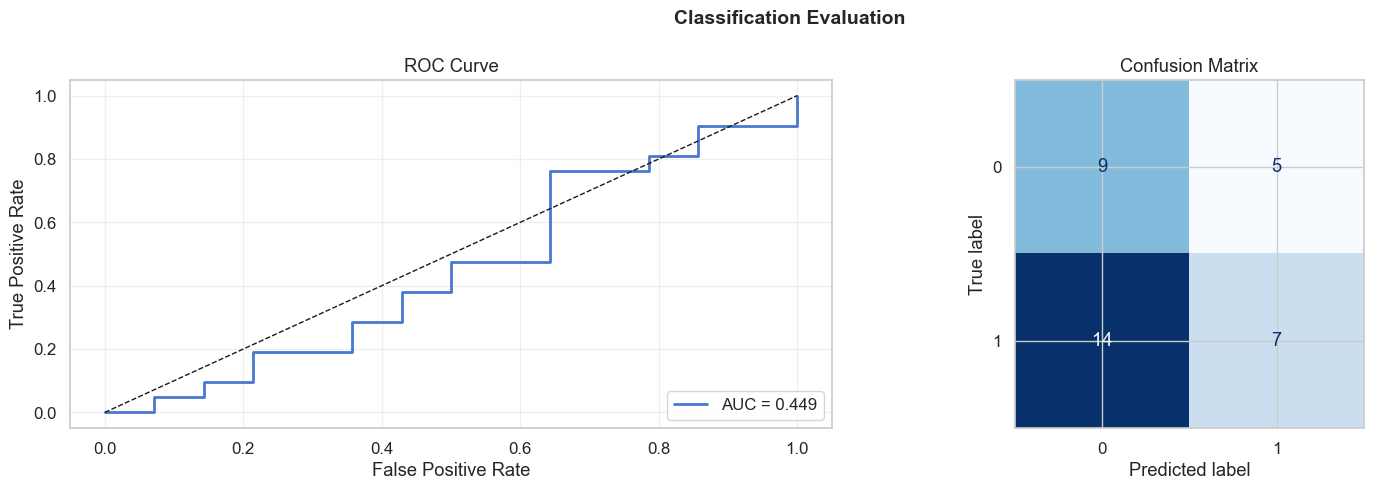

In [95]:
from tidepy.pred import TIDE

ensemble_id = []
for col in nivo_transcriptomic_test.columns:
    ensemble_id.append(col.split('.')[0])

nivo_transcriptomic_tide = nivo_transcriptomic_test.copy().drop(columns = ['Patient_ID'])
nivo_transcriptomic_tide.columns = ensemble_id[1:]
nivo_transcriptomic_tide = nivo_transcriptomic_tide.T

# 2. Run TIDE
# cancer options: 'Melanoma', 'NSCLC', 'Other'
result_tide = TIDE(nivo_transcriptomic_tide, cancer='Other', pretreat=False, ignore_norm=False).sort_index()

y_tide_pred = result_tide['Responder'].map({True: 1, False:0})
y_tide_score = result_tide['TIDE'].values
evaluate(y_tide_pred, y_tide_score)


<a id="anch-cv"></a>\n\n
## **4.2. Model Cross Validation**

In [25]:
logit = LogisticRegression(penalty='l2', random_state=RANDOM_STATE)
            
cv = StratifiedKFold(n_splits=5,shuffle=True, random_state=RANDOM_STATE)

pipeline = Pipeline(
    [
    ('scaler', MinMaxScaler()),
    ('classifier', logit)
    ]
) 

scoring = {
    'roc_auc':   'roc_auc',
    'pr_auc':   'average_precision',
    'f1':        'f1',
    'mcc': 'matthews_corrcoef'
}

for score in scoring.values():
    cv_res = cross_val_score(pipeline, X_full, y_nivo, cv=cv, scoring=score, n_jobs=-1)
    print(f"{score:25s}  {cv_res.mean():.3f}±{cv_res.std():.3f}")

roc_auc                    0.589±0.082
average_precision          0.719±0.055
f1                         0.680±0.078
matthews_corrcoef          0.142±0.172


## **4.3  Evaluation on Hold-out Test Set**

Once satisfied with the Cross-validation results on the training set, we will **train the final pipeline on the entire training set** (`X_full`, `y_nivo`).

Then, we predict responses for the unseen **test set** (`X_full_test`).

Finally, we pass these predictions to the Hackathon's custom `evaluator` utility to score our model.

MCC     : 0.1667
F1      : 0.7451
ROC-AUC : 0.6190
PR-AUC  : 0.7277


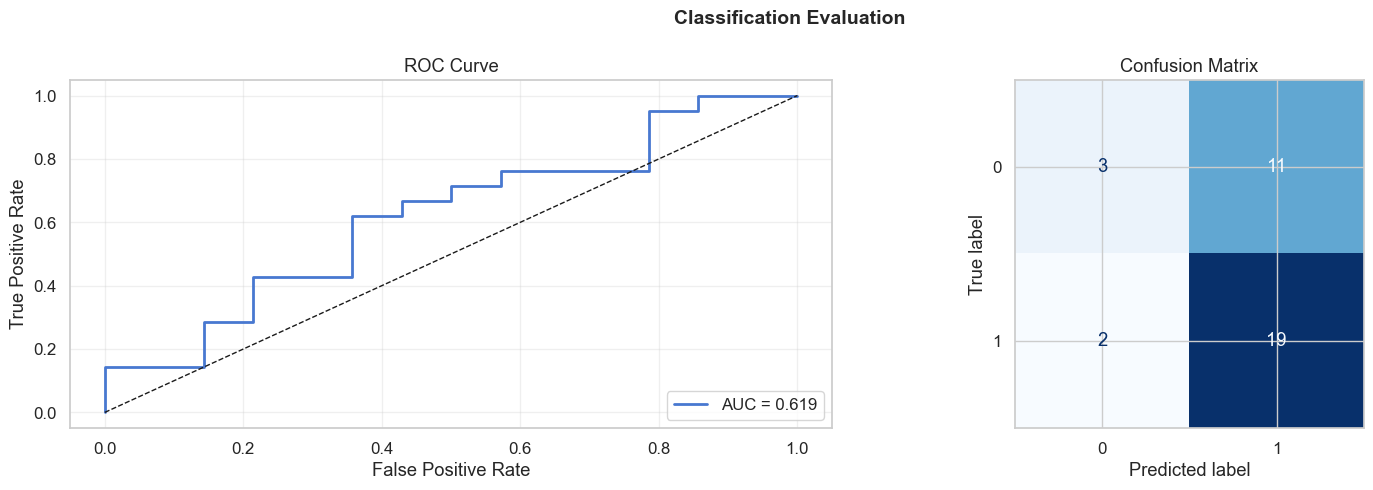

In [36]:
pipeline.fit(X_full, y_nivo)
y_pred = pipeline.predict(X_full_test)
y_proba = pipeline.predict_proba(X_full_test)[:, 1]
evaluate(y_pred, y_proba)

## **4.4. Feature Importance**

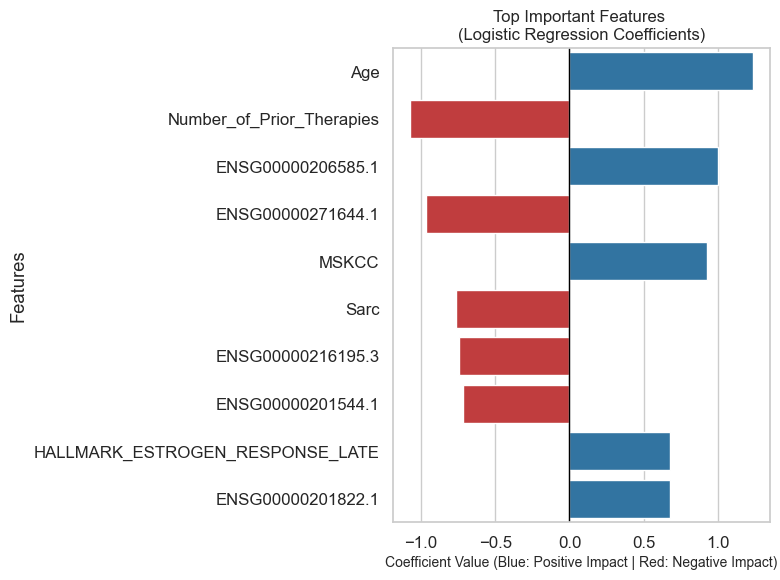

In [40]:
# Extract the trained Logistic Regression model from the pipeline
# Assuming the step was named 'classifier' in your pipeline definition
classifier = pipeline.named_steps['classifier']

# Extract the coefficients for the binary classification
# .coef_ returns a 2D array (1, n_components), we take [0] to get the 1D array
coefficients = classifier.coef_[0]

columns = X_full.columns.tolist()
Features = []
for i in range(len(coefficients)):
    Features.append(columns[i])


importance_df = pd.DataFrame({
    'Features': Features,
    'Coefficient': coefficients,
    'Absolute_Impact': np.abs(coefficients) # Used to rank the most influential PCs
})

# Sort by the absolute magnitude of the impact from highest to lowest
importance_df = importance_df.sort_values(by='Absolute_Impact', ascending=False)

# Visualize the Top Most Important Features
plt.figure(figsize=(8,6))
top_features = importance_df.head(10)

sns.barplot(
    x='Coefficient', 
    y='Features', 
    data=top_features,
    palette=['#d62728' if c < 0 else '#1f77b4' for c in top_features['Coefficient']]
)

plt.axvline(0, color='black', linewidth=1)
plt.title('Top Important Features \n(Logistic Regression Coefficients)', fontsize=12)
plt.xlabel('Coefficient Value (Blue: Positive Impact | Red: Negative Impact)', fontsize=10)
plt.tight_layout()
plt.show()


## **4.5. Learning Curves**
A learning curve helps diagnose **overfitting** (large train–test gap) and
**underfitting** (both curves plateau at low score).

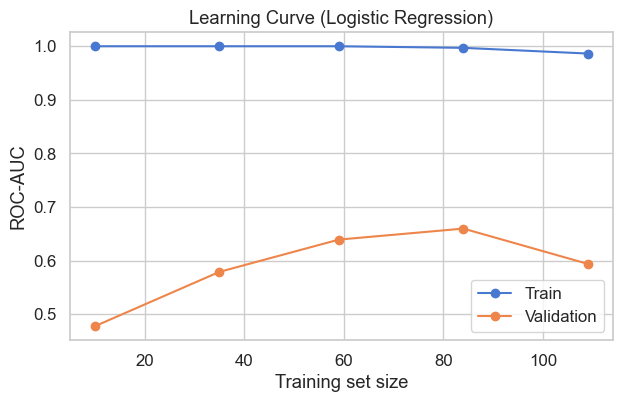

In [ ]:
# ── 4.2 Learning curves (baseline) ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
train_sizes, train_scores, val_scores = learning_curve(
    pipeline, X_full, y_nivo, cv=cv, scoring='roc_auc',
    n_jobs=-1, random_state=RANDOM_STATE)

ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
ax.set_xlabel('Training set size'); ax.set_ylabel('ROC-AUC')
ax.legend()
plt.title('Learning Curve (Logistic Regression)')
plt.show()

<a id="anch-optimization"></a>\n\n
<a id="model-optimization"></a>

# **5. Model Optimization**

## **5.1. Feature Selection & Dimensionality Reduction**


## **5.1.1. Filter Methods: ANOVA F-test**
We use the **ANOVA F-test** via `SelectKBest` to perform univariate feature selection. This method evaluates the linear relationship between each numerical numerical feature and the categorical target, selecting the top $k$ features with the strongest statistical significance.

```python
from sklearn.feature_selection import SelectKBest, f_classif

# k is the number of features you want to keep
selector = SelectKBest(score_func=f_classif, k=20)

X_train_sel = selector.fit_transform(X_train_final, y_train)
print(f"Original feature count: {X_train_final.shape[1]}")
print(f"Selected feature count: {X_train_sel.shape[1]}")
```

---

## **5.1.2. Filter Methods: Mutual Information**
We utilize **Mutual Information (MI)** to capture both linear and non-linear dependencies between features and the target. Unlike the F-test, MI measures information gain, making it more robust for identifying complex biological signals that do not follow a simple linear trend.

```python
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from functools import partial

# We fix the random state because MI has a stochastic component (internal KNN)
mi_func = partial(mutual_info_classif, random_state=RANDOM_STATE)
selector = SelectKBest(score_func=mi_func, k=20)

X_train_sel = selector.fit_transform(X_train_final, y_train)
print(f"Original feature count: {X_train_final.shape[1]}")
print(f"Selected feature count: {X_train_sel.shape[1]}")
```

## **5.1.3. Embedded Methods**
We use **Logistic Regression** to perform embedded feature selection. The `SelectFromModel` class from `sklearn` allows us to select features based on the importance weights learned by the logistic regression model.

```python
model = LogisticRegression(random_state=RANDOM_STATE)
selector = SelectFromModel(model, prefit = False)

X_train_sel = selector.fit_transform(X_train_final, y_train)
print(f"Original feature count: {X_train_final.shape[1]}")
print(f"Selected feature count: {X_train_sel.shape[1]}")
```

## **5.1.4. Wrapper Methods**
We can also use **Recursive Feature Elimination (RFE)** with a logistic regression estimator to iteratively select features by recursively considering smaller and smaller sets of features.

```python
from sklearn.feature_selection import RFE
estimator = LogisticRegression(random_state=RANDOM_STATE)
selector = RFE(estimator, n_features_to_select=20, step=1)
selector = selector.fit(X_train_final, y_train)
X_train_sel = selector.transform(X_train_final)
```

## **5.1.5. ROOFS: RObust biOmarker Feature Selection**

[ROOFS](https://gitlab.inria.fr/compo/roofs) provides a framework for:

- Feature selection: Benchmarking 35+ FS methods (LASSO and variants, statistical tests, ML-based methods, etc.)

- Optimism correction: Unbiased performance estimation using Harrell's method, .632, and .632+ bootstrap correction

- Interactive interface: Streamlit-based GUI for easy pipeline execution

- Automatic reporting: Detailed HTML reports with visualizations and table summaries

## **5.2. Dimensionality Reduction with PCA**
We can apply **Principal Component Analysis (PCA)** to reduce the dimensionality of the transcriptomic features while retaining most of the variance. We can select the number of principal components based on the cumulative explained variance (e.g., retaining 95% of the variance).

```python
from sklearn.decomposition import PCA
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
train_pca_result = pca.fit_transform(X_train_transcriptomic_scaled) 
```

In [ ]:
pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
train_pca_result = pca.fit_transform(nivo_transcriptomic_filtered)
n_pcs = train_pca_result.shape[1]
pca_columns = [f'PC{i+1}' for i in range(n_pcs)]
train_pca_df = pd.DataFrame(
    train_pca_result, 
    columns=pca_columns,
    index=nivo_transcriptomic_filtered.index)

# X_pca = pd.concat([
#     clinical_train_imputed.reset_index(drop=True),
#     nivo_pathway.reset_index(drop=True),
#     nivo_deconv_clr.reset_index(drop=True),
#     nivo_genomic_filled.reset_index(drop=True),
#     train_pca_df.reset_index(drop=True)
# ], axis=1)

# display(X_pca.head(3))


#Apply PCA transform to test set
test_pca_results = pca.transform(test_transcriptomic_filtered)

test_pca_df = pd.DataFrame(
    test_pca_results, 
    columns=pca_columns,
    index=test_transcriptomic_filtered.index)

# X_pca_test = pd.concat([
#     clinical_test_imputed.reset_index(drop=True),
#     nivo_pathway_test.reset_index(drop=True),
#     test_deconv_clr.reset_index(drop=True),
#     test_gen_final,
#     test_pca_df.reset_index(drop=True)
# ], axis=1)

## **5.3. Data Sampling**

### **5.3.1. Oversampling**

- **Oversampling** aims to balance the dataset by increasing the number of samples in the minority class. The simplest form is **Random Oversampling**, which duplicates existing minority instances. While this balances the class distribution, it carries a high risk of **overfitting**, as the model essentially "memorizes" specific data points rather than learning general patterns.

- **SMOTE** is a more sophisticated "informed" oversampling technique. Instead of duplicating rows, it selects a minority class point and identifies its $k$-nearest neighbors. It then creates **synthetic** data points along the line segments connecting these neighbors. This "stretches" the minority class region, helping the model learn a more robust decision boundary and reducing the likelihood of overfitting.

- **ADASYN** builds upon the SMOTE concept but adds an **adaptive** mechanism. It focuses on the "hard-to-learn" parts of the feature space. ADASYN looks for minority samples that are surrounded by many majority class points (the "borderline" or "noisy" areas) and generates more synthetic data there. This forces the model to pay more attention to the most difficult areas where the classes overlap, rather than wasting resources on "easy" areas.

### **5.3.2. Undersampling**

- **Undersampling** balances the dataset by removing instances from the majority class. This is often used when you have a massive dataset and want to reduce computational costs. However, the major drawback is **information loss**—you might discard critical data points that define the majority class's boundary, potentially leading to a model that underperforms on real-world data.

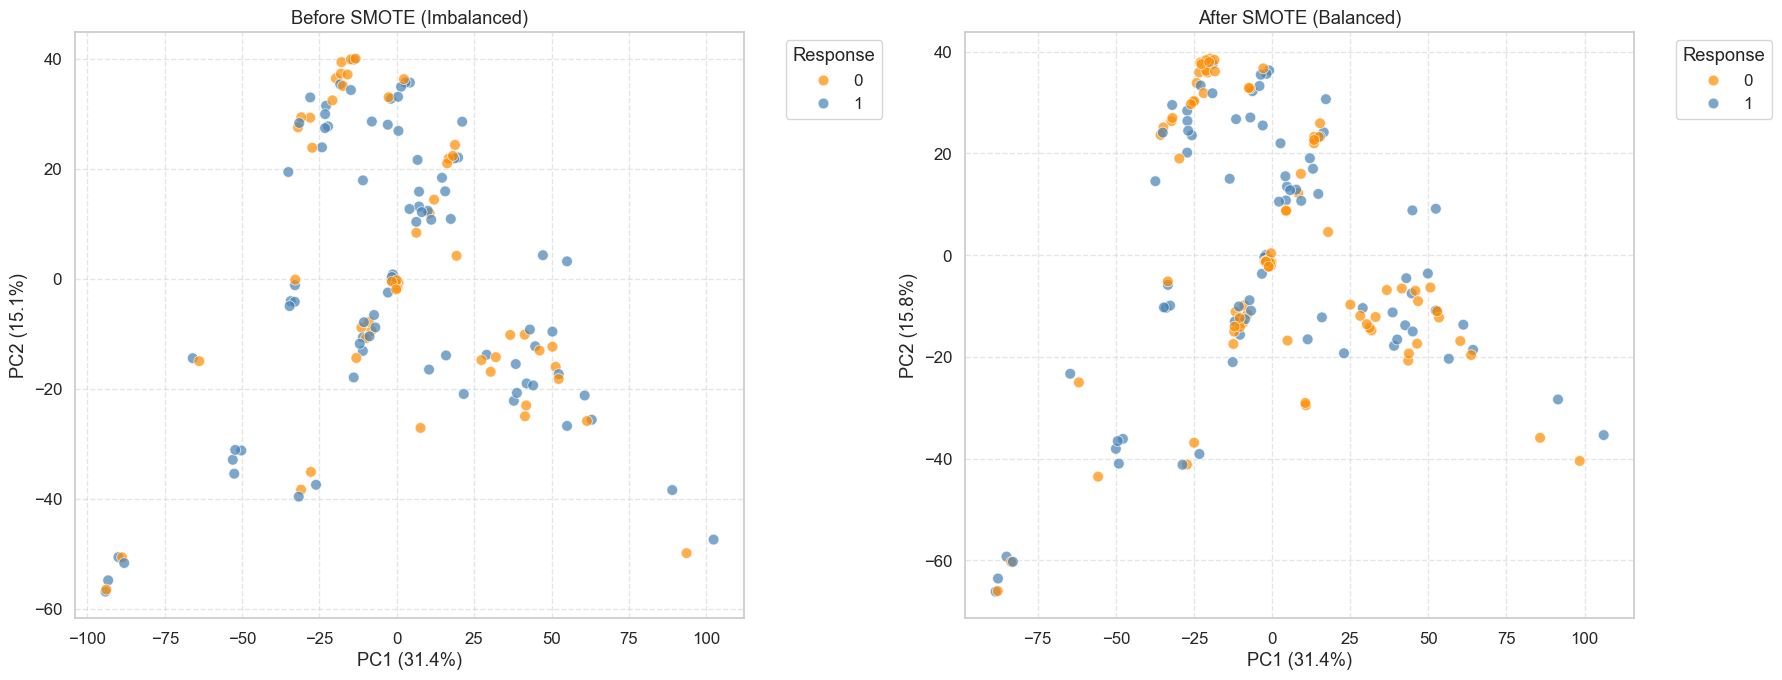

In [ ]:
#Data Sampling with SMOTE
sm = SMOTE(random_state=42)
X_resampled, y_resampled = sm.fit_resample(X_full, y_nivo)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# original dataa
plot_pca_2d(X_full, y_nivo, title="Before SMOTE (Imbalanced)", ax=ax1)

# sampled data
plot_pca_2d(X_resampled, y_resampled, title="After SMOTE (Balanced)", ax=ax2)

plt.tight_layout()
plt.show()

## **5.4. Hyperparameter tunning**

### **5.4.1. GridSearchCV**

- We provide a list of specific values for each hyperparameter, and it trials every possible combination using cross-validation.

- Use for: Small search spaces where you want to be 100% sure you've checked every point in the grid.

```python
from sklearn.model_selection import GridSearchCV

# 1. Define the parameters to test
# Format for pipelines: 'stepname__parametername'
pipeline = Pipeline(
    [
        ('scaler', MinMaxScaler()),
        ('classifier', RandomForestClassifier(random_state=42))
    ]
)
param_grid = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
}

# 2. Setup the Grid Search
grid_search = GridSearchCV(
    estimator=pipeline, 
    param_grid=param_grid, 
    cv=cv, 
    scoring='roc_auc', 
    n_jobs=-1
)

# 3. Fit (This will try every combination)
grid_search.fit(X_full, y_nivo)

print(f"Best Score: {grid_search.best_score_}")
print(f"Best Params: {grid_search.best_params_}")

```

<a id="anch-hyper"></a>\n\n
### **5.4.2. Optuna (Bayesian Optimizaton)**

- Instead of trying every point, it uses previous results to learn which areas of the search space are better and focuses there. It can handle searching ranges.

- Used for: Large search spaces or complex models where trying everything would take too long.

```python
import optuna
from sklearn.model_selection import cross_val_score

def objective(trial):
    # 1. Define the ranges to explore
    pipeline = Pipeline(
    [
        ('scaler', MinMaxScaler()),
        ('classifier', RandomForestClassifier(random_state=42))
    ]
)
    n_estimators = trial.suggest_int('n_estimators', 50, 300)
    max_depth = trial.suggest_int('max_depth', 2, 32)
    
    # 2. Update pipeline params
    pipeline.set_params(
        classifier__n_estimators=n_estimators,
        classifier__max_depth=max_depth
    )
    
    # 3. Use CV score as the quality metric to maximize
    score = cross_val_score(pipeline, X_full, y_nivo, n_jobs=-1, cv=3, scoring='f1')
    return score.mean()

# 4. Create and run the study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20) # Define how many "guesses" it gets

print(f"Best Params: {study.best_params}")
```

<a id="anch-submission"></a>\n\n
<a id="final-submission"></a>

# **6. Submission**

🚀😎📊 If you’re already happy with your model’s performance, go ahead and upload your predictions and notebooks to the Google Form below!

[Click here](https://docs.google.com/forms/d/e/1FAIpQLSc9QLtWeIIeP9OCNEKO2QXzfhRxjUA96X5QrlpOJfr5uIUKvg/viewform?usp=dialog)
